# Kelmarsh Wind Farm SCADA (2016) — power curve, forecasting & anomaly models

The raw SCADA series behind the **WindIQ** demo: 6 × Senvion MM92 (2.05 MW, fleet 12.3 MW) at
Kelmarsh, UK, at **10-minute resolution** through 2016 — `Turbine_Data_*.csv` (wind speed, power,
energy export, theoretical energy) plus `Status_*.csv` stop logs. Dataset: Cubico Sustainable
Investments, CC-BY-4.0, zenodo.org/records/5841834. The dashboard JSON
(`lib/windiq-real.json`) is an aggregate of this same data built by
`python/scripts/build-windiq-data.py` — so the models here and the dashboard metrics must agree.

The modeling arc mirrors the ETT notebooks but for the physics of wind:

1. **SCADA data-quality pass** — regularity, gaps, frozen-sensor runs, implausible values.
2. **Power curve & conformance** — the fleet reference curve, per-turbine conformance /
   availability / deficit (the exact WindIQ KPIs), plus a smooth parametric fit and a
   derating/curtailment screen.
3. **Farm power forecasting — baselines** — persistence vs linear vs gradient boosting at
   1 h / 6 h / 24 h. Wind power is extremely persistent at short horizons and almost
   unpredictable from history alone at 24 h: the honest bar.
4. **The missing signal: future wind speed** — an *oracle* that adds `ws(t+h)` (i.e. a perfect
   NWP forecast) bounds what any model *could* achieve. This is the wind analog of the ETT
   finding that the missing exogenous signal was ambient temperature.
5. **ProbSparse self-attention transformer** (the `models/informer.py` module) — 16 h ahead
   (96/48/96) and 1 h ahead (96/48/6), plus an oracle variant. Persistence is the ceiling at
   1 h; at 16 h the honest optimum is a smart mean level.
6. **Anomaly & availability** — frozen runs, power-curve derating, and the status-log loss
   attribution table the dashboard shows.

All models are persisted under `models/scada_kelmarsh/` (`.joblib` for sklearn, `.pt` + `.json`
for the transformer) by this notebook itself, so the numbers below are the exact saved weights.

## 1. Setup — load the raw 10-minute series

The parser mirrors `build-windiq-data.py` exactly (same columns, same NaN handling) so the
numbers here reproduce the dashboard's. Data lives in `datasets/kelmarsh_2016/`
(`Turbine_Data_*.csv` + `Status_*.csv`); the notebook also works if the folder is next to it.

In [1]:
import glob, os, sys, math, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

RATED_KW = 2050.0        # Senvion MM92 rated power
FLEET_MW = 12.3          # farm capacity
BIN = 0.5                # m/s wind-speed bins for the fleet reference curve

def resolve(name):
    for base in ("datasets", "."):
        p = os.path.join(base, name)
        if os.path.exists(p):
            return p
    return name

SRC = resolve("kelmarsh_2016")
print("data dir:", SRC)

def fnum(s):
    try:
        v = float(s)
        return None if math.isnan(v) else v
    except (ValueError, TypeError):
        return None

def read_turbine(path):
    # one Greenbyte turbine CSV -> list of dicts (same columns the dashboard builder uses)
    with open(path) as f:
        rows = csv_reader = __import__("csv").reader(f)
        hdr = None
        for row in rows:
            if row and row[0].startswith("#") and not row[0].startswith("# Date and time"):
                continue
            if hdr is None:
                row[0] = row[0].lstrip("# ")
                hdr = {name: i for i, name in enumerate(row)}
                cols = {"t": hdr["Date and time"], "ws": hdr["Wind speed (m/s)"],
                        "kw": hdr["Power (kW)"], "exp": hdr["Energy Export (kWh)"],
                        "theo": hdr["Energy Theoretical (kWh)"]}
                continue
            yield {"t": row[cols["t"]], "ws": fnum(row[cols["ws"]]),
                   "kw": fnum(row[cols["kw"]]), "exp": fnum(row[cols["exp"]]),
                   "theo": fnum(row[cols["theo"]])}

turbine_files = sorted(glob.glob(os.path.join(SRC, "Turbine_Data_*.csv")))
status_files  = sorted(glob.glob(os.path.join(SRC, "Status_*.csv")))
print(f"{len(turbine_files)} turbine CSVs, {len(status_files)} status CSVs")

raw = {}
for p in turbine_files:
    num = os.path.basename(p).split("_")[3]
    rows = list(read_turbine(p))
    df = pd.DataFrame(rows)
    df["t"] = pd.to_datetime(df["t"])
    df = df.set_index("t").sort_index()
    raw[num] = df[["ws", "kw", "exp", "theo"]]
    print(f"  turbine {num}: {len(df)} rows  {df.index.min()} -> {df.index.max()}")

# Farm aggregate: sum of turbine power/theoretical (kW), mean wind speed (m/s).
kw = pd.concat([v["kw"] for v in raw.values()], axis=1, keys=raw.keys())
theo = pd.concat([v["theo"] for v in raw.values()], axis=1, keys=raw.keys())
ws = pd.concat([v["ws"] for v in raw.values()], axis=1, keys=raw.keys())
farm = pd.DataFrame({"P": kw.sum(axis=1) / 1000.0,                  # MW
                     "theo": theo.sum(axis=1) * 6 / 1000.0,          # kWh/10min -> kW -> MW
                     "ws": ws.mean(axis=1)})
print(f"farm: {len(farm)} rows, mean P {farm['P'].mean():.2f} MW "
      f"({100*farm['P'].mean()/FLEET_MW:.1f}% capacity factor), peak {farm['P'].max():.2f} MW")

data dir: ./kelmarsh_2016
6 turbine CSVs, 6 status CSVs


  turbine 1: 52416 rows  2016-01-03 00:00:00 -> 2016-12-31 23:50:00


  turbine 2: 52416 rows  2016-01-03 00:00:00 -> 2016-12-31 23:50:00


  turbine 3: 52416 rows  2016-01-03 00:00:00 -> 2016-12-31 23:50:00


  turbine 4: 52416 rows  2016-01-03 00:00:00 -> 2016-12-31 23:50:00


  turbine 5: 52416 rows  2016-01-03 00:00:00 -> 2016-12-31 23:50:00


  turbine 6: 52416 rows  2016-01-03 00:00:00 -> 2016-12-31 23:50:00
farm: 52416 rows, mean P 2.81 MW (22.8% capacity factor), peak 12.34 MW


## 2. SCADA data-quality pass

The same checks a SCADA/historian engineer runs on any new tag feed (and the same lens the ETT
notebooks used on the oil-temperature series): is sampling regular, are there gaps, are any
sensors **stuck** (frozen-value runs — the most common real fault), and are values physically
plausible? A note on **negative power**: a turbine at idle draws a few kW for yaw/heaters/aux,
so `Power (kW) < 0` in small magnitude is *normal* — what matters is how many points are
significantly negative (only a handful, farm-wide). A stuck **wind-speed** sensor is a genuine
fault; a stuck **power** value is only suspicious while the wind is up (a turbine that should be
producing).

In [2]:
import itertools

def stuck_mask(s, min_len=6):
    # True where a value is part of a run of >= min_len identical consecutive values
    # (>= 1 h at 10-min sampling). Vectorized, NaN-safe.
    same = (s == s.shift()).fillna(False)
    grp = (same != same.shift()).cumsum()
    cnt = same.groupby(grp).transform("sum")
    return same & (cnt >= min_len)

print("=== sampling & gaps (farm timestamps) ===")
dts = farm.index.to_series().diff().dropna()
print(f"median dt: {dts.median()}, unique dt: {sorted(dts.unique())}")
expected = pd.date_range(farm.index.min(), farm.index.max(), freq="10min")
print(f"expected {len(expected)} points on a 10-min grid, have {len(farm)} "
      f"({100*len(farm)/len(expected):.1f}%)")

print("\n=== per-turbine quality ===")
qrows = []
for num, df in raw.items():
    n = len(df)
    neg = int((df["kw"] < 0).sum())
    over = int((df["kw"] > RATED_KW * 1.05).sum())
    badws = int(((df["ws"] < 0) | (df["ws"] > 40)).sum())
    st_ws = stuck_mask(df["ws"])                        # frozen wind-speed sensor
    st_kw = stuck_mask(df["kw"]) & (df["ws"] > 4)       # frozen power WHILE windy -> fault
    qrows.append({"turbine": f"KWF-{int(num):02d}", "rows": n,
                  "neg_power": neg, "over_rated": over, "implaus_ws": badws,
                  "stuck_ws_h": round(float(st_ws.sum()) / 6, 1),
                  "stuck_kw_while_windy_h": round(float(st_kw.sum()) / 6, 1)})
print(pd.DataFrame(qrows).to_string(index=False))

print("\n=== farm-level plausibility ===")
print(f"farm negative-power points: {(farm['P'] < 0).sum()}  "
      f"({(farm['P'] < -0.05).sum()} below -0.05 MW)")
print(f"farm P > capacity: {(farm['P'] > FLEET_MW).sum()}  | farm ws > 40: {(farm['ws'] > 40).sum()}")
print(f"missing farm timestamps (any turbine absent): {farm['P'].isna().sum()}")

=== sampling & gaps (farm timestamps) ===
median dt: 0 days 00:10:00, unique dt: [Timedelta('0 days 00:10:00')]
expected 52416 points on a 10-min grid, have 52416 (100.0%)

=== per-turbine quality ===
turbine  rows  neg_power  over_rated  implaus_ws  stuck_ws_h  stuck_kw_while_windy_h
 KWF-01 52416       6419           0           0         0.0                     0.0
 KWF-02 52416       5090           0           0         0.0                     0.0
 KWF-03 52416       6046           0           0         0.0                     0.0
 KWF-04 52416       4564           0           0         0.0                     2.5
 KWF-05 52416       7072           0           0         0.0                     0.0
 KWF-06 52416       6602           0           0         0.0                     0.0

=== farm-level plausibility ===
farm negative-power points: 4035  (4 below -0.05 MW)
farm P > capacity: 12  | farm ws > 40: 0
missing farm timestamps (any turbine absent): 0


## 3. Power curve & conformance — the WindIQ KPIs

The fleet **reference power curve** is the mean power in each 0.5 m/s wind-speed bin across all
turbines (exactly how `build-windiq-data.py` builds it). Per-turbine **conformance** is
`100 × actual energy / reference-expected energy` over that curve, **availability** is the
energy-based ratio `Energy Export / Energy Theoretical` (the Greenbyte theoretical is the turbine
running at its own curve), and **deficit** is the MWh the unit sat below the fleet reference.
These three numbers are the dashboard's headline KPIs — this cell must reproduce
`lib/windiq-real.json` to the digit.

A smooth **parametric fit** (3-parameter logistic) is also fit per turbine — the classic SCADA
power-curve model used to flag units that drift off the fleet behaviour.

In [3]:
# --- fleet reference curve (bin-mean, n >= 50) ---
bins = defaultdict(lambda: [0.0, 0])
for num, df in raw.items():
    m = df["ws"].notna() & df["kw"].notna()
    for ws, kw in zip(df.loc[m, "ws"], df.loc[m, "kw"]):
        b = round(ws / BIN) * BIN
        bins[b][0] += kw
        bins[b][1] += 1
ref = {b: s / n for b, (s, n) in bins.items() if n >= 50}
bins_arr = np.array(sorted(ref))
ref_arr = np.array([ref[b] for b in bins_arr])

# --- per-turbine conformance / availability / deficit (dashboard definitions) ---
from scipy.optimize import curve_fit

def sig(ws, a, b, c):
    return a / (1 + np.exp(-(ws - b) / c))

trows = []
for num, df in raw.items():
    actual = expect = 0.0
    exp_kwh = theo_kwh = 0.0
    for r in df.itertuples():
        if pd.notna(r.exp):
            exp_kwh += r.exp
        if pd.notna(r.theo):
            theo_kwh += r.theo
        if pd.isna(r.ws) or pd.isna(r.kw) or round(r.ws / BIN) * BIN not in ref:
            continue
        actual += max(r.kw, 0)
        expect += ref[round(r.ws / BIN) * BIN]
    conf = 100 * actual / expect if expect else 0
    avail = 100 * exp_kwh / theo_kwh if theo_kwh else 0
    deficit = max(0.0, (expect - actual) / 6 / 1000)
    # parametric fit on in-range points
    m = df["ws"].notna() & df["kw"].notna() & (df["ws"] >= 0) & (df["ws"] <= 26) & (df["kw"] >= 0)
    try:
        popt, _ = curve_fit(sig, df.loc[m, "ws"], df.loc[m, "kw"],
                            p0=[2050, 9, 1.5], bounds=([0, 0, 0.3], [2600, 30, 10]), maxfev=40000)
    except Exception:
        popt = [np.nan] * 3
    trows.append({"id": f"KWF-{int(num):02d}", "conformance": round(conf, 1),
                  "availability": round(avail, 1), "deficitMwh": round(deficit, 1),
                  "sig_a": round(popt[0]), "sig_b": round(popt[1], 2), "sig_c": round(popt[2], 2)})

tbl = pd.DataFrame(trows)
print("=== computed (must match lib/windiq-real.json) ===")
print(tbl.to_string(index=False))

dash_path = next(p for p in ("../../lib/windiq-real.json", "../lib/windiq-real.json",
                             "lib/windiq-real.json") if os.path.exists(p))
dash = json.load(open(dash_path))
d = {t["id"]: t for t in dash["turbines"]}
print("\n=== vs dashboard json (diff) ===")
for _, r in tbl.iterrows():
    g = d[r["id"]]
    diff = {k: round(r[k] - g[k], 2) for k in ("conformance", "availability", "deficitMwh")}
    print(f"  {r['id']}: {diff}")

=== computed (must match lib/windiq-real.json) ===
    id  conformance  availability  deficitMwh  sig_a  sig_b  sig_c
KWF-01         95.2          90.9       213.5   1922   7.90   1.35
KWF-02        103.8          95.0         0.0   1955   7.79   1.32
KWF-03         99.6          88.7        15.6   1771   7.53   1.22
KWF-04        104.4          91.5         0.0   1866   7.67   1.28
KWF-05         96.5          85.9       139.0   1875   7.62   1.29
KWF-06        100.6          74.2         0.0   1807   7.60   1.26

=== vs dashboard json (diff) ===
  KWF-01: {'conformance': 0.0, 'availability': 0.0, 'deficitMwh': 0.0}
  KWF-02: {'conformance': 0.0, 'availability': 0.0, 'deficitMwh': 0.0}
  KWF-03: {'conformance': 0.0, 'availability': 0.0, 'deficitMwh': 0.0}
  KWF-04: {'conformance': 0.0, 'availability': 0.0, 'deficitMwh': 0.0}
  KWF-05: {'conformance': 0.0, 'availability': 0.0, 'deficitMwh': 0.0}
  KWF-06: {'conformance': 0.0, 'availability': 0.0, 'deficitMwh': 0.0}


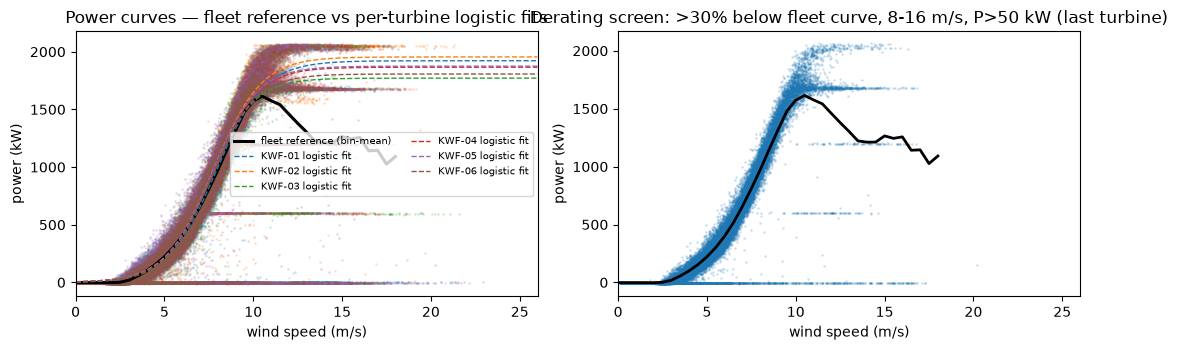

turbine  derate_pts  derate_hours  derate_mwh
 KWF-01         155          25.8        20.0
 KWF-02         208          34.7        27.0
 KWF-03         229          38.2        30.9
 KWF-04         121          20.2        14.0
 KWF-05         111          18.5        13.2
 KWF-06          98          16.3        13.9


In [4]:
# --- reference curve plot + derating screen ---
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
for num, df in raw.items():
    ax.scatter(df["ws"], df["kw"], s=1, alpha=0.15, rasterized=True)
ax.plot(bins_arr, ref_arr, "k-", lw=2.2, label="fleet reference (bin-mean)")
ws_grid = np.linspace(0, 26, 300)
for _, r in tbl.iterrows():
    ax.plot(ws_grid, sig(ws_grid, r["sig_a"], r["sig_b"], r["sig_c"]), lw=1.0, ls="--",
            label=f"{r['id']} logistic fit")
ax.set_xlabel("wind speed (m/s)"); ax.set_ylabel("power (kW)")
ax.set_title("Power curves — fleet reference vs per-turbine logistic fits")
ax.legend(fontsize=7, ncol=2); ax.set_xlim(0, 26)

# derating / curtailment candidates: producing but well below the fleet curve at mid-high wind
ax2 = axes[1]
flags = []
for num, df in raw.items():
    mm = df[df["ws"].notna() & df["kw"].notna()]
    exp_pt = np.array([ref.get(round(w / BIN) * BIN, np.nan) for w in mm["ws"]])
    resid = mm["kw"].values - exp_pt
    bad = ((mm["ws"].values >= 8) & (mm["ws"].values <= 16) & (mm["kw"].values > 50)
           & (resid < -0.3 * exp_pt))
    n_pts = int(bad.sum())
    mwh = float((np.maximum(exp_pt[bad], 0) - mm["kw"].values[bad]).sum() / 6 / 1000) if n_pts else 0.0
    flags.append({"turbine": f"KWF-{int(num):02d}", "derate_pts": n_pts,
                  "derate_hours": round(n_pts / 6, 1), "derate_mwh": round(mwh, 1)})
    if int(num) == len(raw):
        ax2.scatter(mm["ws"], mm["kw"], s=1, alpha=0.15, rasterized=True)
        ax2.plot(bins_arr, ref_arr, "k-", lw=2)
        ax2.set_xlabel("wind speed (m/s)"); ax2.set_ylabel("power (kW)")
        ax2.set_title("Derating screen: >30% below fleet curve, 8-16 m/s, P>50 kW (last turbine)")
        ax2.set_xlim(0, 26)
plt.tight_layout(); plt.show()
print(pd.DataFrame(flags).to_string(index=False))

## 4. Farm power forecasting — baselines (persistence / linear / GBDT)

Target: farm power `P(t+h)` in MW at h = 1 h / 6 h / 24 h (6 / 36 / 144 ten-minute steps).
Temporal split 70/10/20 over the year. Features are **history-only**: power/wind-speed/theoretical
lags plus calendar (hour-of-day, day-of-year sines). Persistence (`P(t)`) is the bar — wind power
autocorrelation at 1 h is ~0.95+, so persistence is brutally strong at short horizons. At 24 h a
learned model has nothing to work with except the seasonal level, so the honest comparison also
includes a **constant mean-power forecast**.

In [5]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error

os.environ.setdefault("OMP_NUM_THREADS", "4")   # avoid OpenMP barrier thrashing

HOURS = [1, 6, 24]
H_STEPS = [h * 6 for h in HOURS]
LAGS = [0, 1, 6, 36, 144]                        # now, 10min, 1h, 6h, 24h ago
CH = ["P", "ws", "theo"]

s = farm.dropna().copy()
n = len(s)
i_tr, i_va = int(0.7 * n), int(0.8 * n)
print(f"rows {n} | train {i_tr} | val {i_va - i_tr} | test {n - i_va}")

def feats(s, h, oracle=False):
    cols = {}
    for c in CH:
        for lag in LAGS:
            cols[f"{c}_l{lag}"] = s[c].shift(lag)
    t = s.index
    hour = t.hour + t.minute / 60
    doy = t.dayofyear
    cols["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    cols["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    cols["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    cols["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    if oracle:
        cols["ws_future"] = s["ws"].shift(-h)     # perfect NWP (leakage, diagnostic only)
    X = pd.DataFrame(cols)
    y = s["P"].shift(-h)
    df = X.copy(); df["y"] = y
    df = df.dropna()
    return df.drop(columns="y").values, df["y"].values

rows = []
for h in H_STEPS:
    X, y = feats(s, h)
    Xtr, ytr = X[:i_tr], y[:i_tr]
    Xva, yva = X[i_tr:i_va], y[i_tr:i_va]
    Xte, yte = X[i_va:], y[i_va:]
    pers = np.abs(yte - Xte[:, 0])               # persistence: P(t) -> P(t+h) (feature P_l0)
    const = np.abs(yte - ytr.mean())             # constant mean-power forecast
    lin = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr, ytr)
    hgb = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08,
                                        max_leaf_nodes=31, random_state=0).fit(Xtr, ytr)
    rows.append({"h": f"{h//6}h", "persistence": pers.mean(),
                 "constant_mean": const.mean(),
                 "linear": mean_absolute_error(yte, lin.predict(Xte)),
                 "gbdt": mean_absolute_error(yte, hgb.predict(Xte))})

res = pd.DataFrame(rows).set_index("h")
print("\n=== farm power forecast MAE (MW) — history-only features ===")
print(res.round(3).to_string())
print("\n=== same, % of fleet capacity (12.3 MW) ===")
print((100 * res / FLEET_MW).round(1).to_string())

rows 48940 | train 34258 | val 4894 | test 9788



=== farm power forecast MAE (MW) — history-only features ===
     persistence  constant_mean  linear   gbdt
h                                             
1h         0.956          2.545   0.969  1.094
6h         1.876          2.549   1.847  2.088
24h        2.707          2.561   2.407  2.655

=== same, % of fleet capacity (12.3 MW) ===
     persistence  constant_mean  linear  gbdt
h                                            
1h           7.8           20.7     7.9   8.9
6h          15.3           20.7    15.0  17.0
24h         22.0           20.8    19.6  21.6


In [6]:
# --- save the linear models + metadata ---
import joblib

def models_dir():
    for base in ("models", "../models"):
        if os.path.isdir(base):
            return base
    os.makedirs("models", exist_ok=True)
    return "models"

mdir = os.path.join(models_dir(), "scada_kelmarsh")
os.makedirs(mdir, exist_ok=True)

saved = {}
for h in H_STEPS:
    X, y = feats(s, h)
    Xtr, ytr = X[:i_tr], y[:i_tr]
    Xte, yte = X[i_va:], y[i_va:]
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr, ytr)
    p = os.path.join(mdir, f"power_linear_h{h//6}.joblib")
    joblib.dump(m, p)
    saved[f"h{h//6}h"] = round(float(mean_absolute_error(yte, m.predict(Xte))), 3)
    print("saved", p)

meta = {"dataset": "Kelmarsh SCADA 2016 (zenodo 5841834)", "target": "farm power MW",
        "split": "70/10/20 temporal", "features": [f"{c}_l{lag}" for c in CH for lag in LAGS]
        + ["hour_sin", "hour_cos", "doy_sin", "doy_cos"],
        "test_mae_mw": saved, "capacity_mw": FLEET_MW,
        "saved_by": "kelmarsh_scada_analysis.ipynb"}
with open(os.path.join(mdir, "power_linear_metadata.json"), "w") as f:
    json.dump(meta, f, indent=1)
print("metadata ->", os.path.join(mdir, "power_linear_metadata.json"))

saved ../models/scada_kelmarsh/power_linear_h1.joblib
saved ../models/scada_kelmarsh/power_linear_h6.joblib
saved ../models/scada_kelmarsh/power_linear_h24.joblib
metadata -> ../models/scada_kelmarsh/power_linear_metadata.json


## 5. The missing signal — future wind speed (the "perfect NWP" oracle)

The ETT arc found the missing exogenous signal was **ambient temperature**. For wind power the
equivalent is the **future wind speed** — a model with `ws(t+h)` (a perfect numerical weather
prediction) can map it through the power curve. Adding it to the *same linear features* is
leakage, but deliberately so: it is the **oracle upper bound** on what any real forecast (with a
good-enough NWP) could achieve. This quantifies the value of a wind forecast — the thing WindIQ
would actually sell against.

In [7]:
oracle_rows = []
for h in H_STEPS:
    X, y = feats(s, h, oracle=True)
    Xtr, ytr = X[:i_tr], y[:i_tr]
    Xte, yte = X[i_va:], y[i_va:]
    m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(Xtr, ytr)
    base = res.loc[f"{h//6}h", "linear"]
    oracle_rows.append({"h": f"{h//6}h", "linear_history_only": base,
                        "linear_+_ws(t+h)": mean_absolute_error(yte, m.predict(Xte))})
orc = pd.DataFrame(oracle_rows).set_index("h")
print("=== MAE (MW): history-only vs + perfect future wind speed (oracle bound) ===")
print(orc.round(3).to_string())
print("\n=== % of capacity ===")
print((100 * orc / FLEET_MW).round(1).to_string())
print(f"\nvalue of a perfect 24 h wind forecast: "
      f"{(orc.loc['24h','linear_history_only'] - orc.loc['24h','linear_+_ws(t+h)']):.3f} MW "
      f"({100*(orc.loc['24h','linear_history_only'] - orc.loc['24h','linear_+_ws(t+h)'])/FLEET_MW:.1f}% of capacity)")

=== MAE (MW): history-only vs + perfect future wind speed (oracle bound) ===
     linear_history_only  linear_+_ws(t+h)
h                                         
1h                 0.969             0.520
6h                 1.847             0.824
24h                2.407             0.949

=== % of capacity ===
     linear_history_only  linear_+_ws(t+h)
h                                         
1h                   7.9               4.2
6h                  15.0               6.7
24h                 19.6               7.7

value of a perfect 24 h wind forecast: 1.458 MW (11.9% of capacity)


## 6. ProbSparse self-attention transformer

Same `Informer` module as the ETT notebook (`models/informer.py`, Zhou et al. AAAI 2021 —
ProbSparse attention keeps the top-u queries by sparsity and fills the rest with mean(V),
O(L²) → O(L ln L)). Channels: **[P, ws, theo]** (MW, m/s, MW), standardized on the train split.

Two honest setups plus one oracle:

- **96/48/6** (1 h ahead) — persistence should crush this; the transformer's copy deficit (the
  ETT finding) should show up again.
- **96/48/96** (16 h ahead) — here the physics flips: persistence is useless at 16 h and the
  optimal history-only forecast is a smart mean level; the transformer should beat persistence.
- **96/48/96 oracle** — decoder gets the *true* future `ws` in the prediction part (perfect NWP,
  leakage-labeled): the transformer can reconstruct the power curve from wind speed and should
  beat everything, quantifying the NWP ceiling for the deep model too.

Windows slide with stride 8 (train) / 3 (eval) so epochs stay cheap; each model saves its best
validation state to `models/scada_kelmarsh/`.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

sys.path.insert(0, os.getcwd())
sys.path.insert(0, os.path.join(os.getcwd(), ".."))
from models.informer import Informer

torch.manual_seed(0)
np.random.seed(0)
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
print("device:", DEV, "| torch", torch.__version__)

SEQ, LABEL = 96, 48
BATCH = 64
CFG = dict(d_model=128, n_heads=8, d_ff=256, e_layers=3, d_layers=1,
           dropout=0.1, factor=5)
CH3 = ["P", "ws", "theo"]
Z = s[CH3].values.astype(np.float32)            # regular farm series, no NaNs
mu, sd = Z[:i_tr].mean(axis=0), Z[:i_tr].std(axis=0)
Z = (Z - mu) / sd
print("channel means/std (train):", dict(zip(CH3, zip(mu.round(3), sd.round(3)))))

def make_windows(Z, pred_len, stride, oracle=False):
    Xe, Xd, Y = [], [], []
    T = len(Z)
    for t in range(0, T - SEQ - pred_len + 1, stride):
        x_enc = Z[t:t + SEQ]
        dec = np.zeros((LABEL + pred_len, Z.shape[1]), dtype=np.float32)
        dec[:LABEL] = Z[t + SEQ - LABEL:t + SEQ]
        if oracle:
            # perfect-NWP channel: fill ws (index 1) of the prediction part with true future ws
            dec[LABEL:, 1] = Z[t + SEQ:t + SEQ + pred_len, 1]
        Xe.append(x_enc); Xd.append(dec); Y.append(Z[t + SEQ:t + SEQ + pred_len, 0])
    return (np.array(Xe), np.array(Xd), np.array(Y))

def batches(data, bs, shuffle=True, seed=0):
    Xe, Xd, Y = data
    n = len(Xe)
    idx = np.arange(n)
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(idx)
    for i in range(0, n, bs):
        b = idx[i:i + bs]
        yield (torch.tensor(Xe[b], device=DEV), torch.tensor(Xd[b], device=DEV),
               torch.tensor(Y[b], device=DEV))

def evaluate(model, data, mu_p, sd_p):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xe, Xd, Y in batches(data, 128, shuffle=False):
            preds.append(model(Xe, Xd)[:, :, 0].cpu().numpy())
            trues.append(Y.cpu().numpy())
    p, t = np.concatenate(preds), np.concatenate(trues)
    p = p * sd_p + mu_p
    t = t * sd_p + mu_p
    return {"mae_all": float(np.abs(p - t).mean()),
            "mae_per_step": np.abs(p - t).mean(axis=0)}

def persistence_mae(data, mu_p, sd_p):
    Xe, _, Y = data
    last = Xe[:, -1, 0] * sd_p + mu_p
    true = Y * sd_p + mu_p
    return np.abs(true - last[:, None]).mean(axis=0)

def train_model(model, tr, va, mu_p, sd_p, epochs=25, lr=1e-3, patience=8, tag="run"):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best_mae, best_state, bad, t0 = float("inf"), None, 0, time.time()
    for epoch in range(epochs):
        model.train()
        tot = 0.0
        for Xe, Xd, Y in batches(tr, BATCH, seed=epoch):
            opt.zero_grad()
            loss = F.mse_loss(model(Xe, Xd), Y.unsqueeze(-1))
            loss.backward(); opt.step()
            tot += loss.item() * len(Xe)
        sched.step()
        va_mae = evaluate(model, va, mu_p, sd_p)["mae_all"]
        print(f"  [{tag}] epoch {epoch+1:>2}/{epochs}: train MSE {tot/len(tr[0]):.5f} "
              f"| val MAE {va_mae:.3f} MW | {time.time()-t0:.0f}s")
        if va_mae < best_mae:
            best_mae, bad = va_mae, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                print(f"  [{tag}] early stop at epoch {epoch+1}")
                break
    model.load_state_dict(best_state)
    return best_mae

def save_checkpoint(name, model, pred_len, oracle, best_mae, mae_step):
    d = os.path.join(models_dir(), "scada_kelmarsh")
    os.makedirs(d, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(d, name + ".pt"))
    meta = {"model": name, "arch": type(model).__name__, "enc_in": 3,
            "config": {**CFG, "seq_len": SEQ, "label_len": LABEL, "pred_len": pred_len,
                       "sparse": True},
            "channels": CH3, "perfect_nwp_oracle": oracle, "device": DEV,
            "channel_sd": [float(x) for x in sd], "channel_mean": [float(x) for x in mu],
            "target": "farm power MW", "capacity_mw": FLEET_MW,
            "val_mae_all": round(float(best_mae), 3),
            "test_mae_per_step": [round(float(x), 3) for x in mae_step],
            "test_mae_all": round(float(np.mean(mae_step)), 3),
            "saved_by": "kelmarsh_scada_analysis.ipynb"}
    with open(os.path.join(d, name + ".json"), "w") as f:
        json.dump(meta, f, indent=1)
    print(f"  saved -> {os.path.join(d, name + '.pt')}")

device: mps | torch 2.13.0
channel means/std (train): {'P': (np.float32(2.849), np.float32(2.859)), 'ws': (np.float32(6.112), np.float32(2.74)), 'theo': (np.float32(3.454), np.float32(3.243))}


In [9]:
EPOCHS = 25
results = {}
mu_p, sd_p = mu[0], sd[0]

# ---- 96/48/6 : 1 h ahead ----
tr6 = make_windows(Z[:i_tr], 6, 8)
va6 = make_windows(Z[i_tr:i_va], 6, 3)
te6 = make_windows(Z[i_va:], 6, 3)
m6 = Informer(enc_in=3, seq_len=SEQ, label_len=LABEL, pred_len=6, **CFG).to(DEV)
best6 = train_model(m6, tr6, va6, mu_p, sd_p, epochs=EPOCHS, tag="96->6")
p6 = persistence_mae(te6, mu_p, sd_p)
e6 = evaluate(m6, te6, mu_p, sd_p)
save_checkpoint("informer_power_96_6", m6, 6, False, best6, e6["mae_per_step"])
results["96->6"] = {"persistence": float(p6.mean()), "transformer": e6["mae_all"]}
print(f"  test MAE (MW): persistence {p6.mean():.3f} | transformer {e6['mae_all']:.3f}")
print(f"  per-step: persistence {np.round(p6,3)} \n            transformer {np.round(e6['mae_per_step'],3)}")

  [96->6] epoch  1/25: train MSE 0.37528 | val MAE 1.131 MW | 3s


  [96->6] epoch  2/25: train MSE 0.18295 | val MAE 0.783 MW | 6s


  [96->6] epoch  3/25: train MSE 0.13683 | val MAE 0.719 MW | 8s


  [96->6] epoch  4/25: train MSE 0.13375 | val MAE 0.725 MW | 11s


  [96->6] epoch  5/25: train MSE 0.13249 | val MAE 0.753 MW | 13s


...

  [96->6] epoch 11/25: train MSE 0.12437 | val MAE 0.724 MW | 27s


  [96->6] epoch 12/25: train MSE 0.12363 | val MAE 0.729 MW | 29s


  [96->6] epoch 13/25: train MSE 0.12182 | val MAE 0.723 MW | 32s


  [96->6] epoch 14/25: train MSE 0.12178 | val MAE 0.732 MW | 34s
  [96->6] early stop at epoch 14


  saved -> ../models/scada_kelmarsh/informer_power_96_6.pt
  test MAE (MW): persistence 0.734 | transformer 0.793
  per-step: persistence [0.404 0.608 0.718 0.809 0.909 0.958] 
            transformer [0.515 0.686 0.775 0.852 0.941 0.991]


In [10]:
# ---- 96/48/96 : 16 h ahead ----
tr96 = make_windows(Z[:i_tr], 96, 8)
va96 = make_windows(Z[i_tr:i_va], 96, 3)
te96 = make_windows(Z[i_va:], 96, 3)
m96 = Informer(enc_in=3, seq_len=SEQ, label_len=LABEL, pred_len=96, **CFG).to(DEV)
best96 = train_model(m96, tr96, va96, mu_p, sd_p, epochs=EPOCHS, tag="96->96")
p96 = persistence_mae(te96, mu_p, sd_p)
c96 = np.abs(te96[2] * sd_p + mu_p - mu_p)      # constant mean-power forecast on same windows
e96 = evaluate(m96, te96, mu_p, sd_p)
save_checkpoint("informer_power_96_96", m96, 96, False, best96, e96["mae_per_step"])
results["96->96"] = {"persistence": float(p96.mean()), "constant_mean": float(c96.mean()),
                     "transformer": e96["mae_all"]}
print(f"  test MAE (MW): persistence {p96.mean():.3f} | constant mean {c96.mean():.3f} "
      f"| transformer {e96['mae_all']:.3f}")
print(f"  per-step (first 12): persistence {np.round(p96[:12],3)}\n"
      f"                      transformer {np.round(e96['mae_per_step'][:12],3)}")

  [96->96] epoch  1/25: train MSE 0.77278 | val MAE 1.694 MW | 2s


  [96->96] epoch  2/25: train MSE 0.65936 | val MAE 1.713 MW | 5s


  [96->96] epoch  3/25: train MSE 0.65052 | val MAE 1.629 MW | 7s


  [96->96] epoch  4/25: train MSE 0.62195 | val MAE 1.588 MW | 9s


  [96->96] epoch  5/25: train MSE 0.57939 | val MAE 1.624 MW | 12s


...

  [96->96] epoch 15/25: train MSE 0.41175 | val MAE 1.722 MW | 35s


  [96->96] epoch 16/25: train MSE 0.38015 | val MAE 1.687 MW | 37s


  [96->96] epoch 17/25: train MSE 0.35723 | val MAE 1.683 MW | 39s


  [96->96] epoch 18/25: train MSE 0.33248 | val MAE 1.715 MW | 42s
  [96->96] early stop at epoch 18


  saved -> ../models/scada_kelmarsh/informer_power_96_96.pt
  test MAE (MW): persistence 1.970 | constant mean 2.550 | transformer 1.882
  per-step (first 12): persistence [0.402 0.607 0.718 0.807 0.908 0.959 1.    1.058 1.098 1.148 1.197 1.226]
                      transformer [0.645 0.828 0.892 0.974 1.015 1.06  1.18  1.245 1.211 1.314 1.323 1.326]


In [11]:
# ---- 96/48/96 oracle : decoder gets true future wind speed (perfect NWP, leakage) ----
trO = make_windows(Z[:i_tr], 96, 8, oracle=True)
vaO = make_windows(Z[i_tr:i_va], 96, 3, oracle=True)
teO = make_windows(Z[i_va:], 96, 3, oracle=True)
mO = Informer(enc_in=3, seq_len=SEQ, label_len=LABEL, pred_len=96, **CFG).to(DEV)
bestO = train_model(mO, trO, vaO, mu_p, sd_p, epochs=EPOCHS, tag="96->96 oracle")
eO = evaluate(mO, teO, mu_p, sd_p)
save_checkpoint("informer_power_96_96_oracle", mO, 96, True, bestO, eO["mae_per_step"])
results["96->96 oracle"] = {"persistence": float(p96.mean()), "constant_mean": float(c96.mean()),
                            "transformer": eO["mae_all"]}
print(f"  test MAE (MW): persistence {p96.mean():.3f} | constant mean {c96.mean():.3f} "
      f"| oracle transformer {eO['mae_all']:.3f}")
print("\n=== summary: 16 h-ahead test MAE (MW) ===")
print(pd.DataFrame(results).T.round(3).to_string())
print("\n=== % of fleet capacity ===")
print((100 * pd.DataFrame(results).T / FLEET_MW).round(1).to_string())

  [96->96 oracle] epoch  1/25: train MSE 0.13620 | val MAE 0.206 MW | 3s


  [96->96 oracle] epoch  2/25: train MSE 0.04141 | val MAE 0.189 MW | 5s


  [96->96 oracle] epoch  3/25: train MSE 0.04228 | val MAE 0.205 MW | 8s


  [96->96 oracle] epoch  4/25: train MSE 0.03829 | val MAE 0.212 MW | 10s


  [96->96 oracle] epoch  5/25: train MSE 0.03691 | val MAE 0.226 MW | 12s


...

  [96->96 oracle] epoch 22/25: train MSE 0.01707 | val MAE 0.164 MW | 51s


  [96->96 oracle] epoch 23/25: train MSE 0.01683 | val MAE 0.162 MW | 53s


  [96->96 oracle] epoch 24/25: train MSE 0.01670 | val MAE 0.164 MW | 56s


  [96->96 oracle] epoch 25/25: train MSE 0.01659 | val MAE 0.163 MW | 58s


  saved -> ../models/scada_kelmarsh/informer_power_96_96_oracle.pt
  test MAE (MW): persistence 1.970 | constant mean 2.550 | oracle transformer 0.295

=== summary: 16 h-ahead test MAE (MW) ===
               persistence  transformer  constant_mean
96->6                0.734        0.793            NaN
96->96               1.970        1.882           2.55
96->96 oracle        1.970        0.295           2.55

=== % of fleet capacity ===
               persistence  transformer  constant_mean
96->6                  6.0          6.4            NaN
96->96                16.0         15.3           20.7
96->96 oracle         16.0          2.4           20.7


## 7. Anomaly & availability

Three operational outputs, all reproducible from the raw files:

1. **Frozen-sensor runs** (from §2) — stuck-value events ≥ 1 h, the classic SCADA fault mode.
2. **Power-curve derating** (from §3) — producing points >30% below the fleet curve in the
   8–16 m/s band: curtailment / wake / yaw-error candidates, in MWh.
3. **Status-log loss attribution** — the `Status_*.csv` stops converted to MWh with the fleet's
   mean operating power, exactly as the dashboard's loss table is built.

In [12]:
# --- status-log loss attribution (dashboard definition) ---
# mean operating power of ONE turbine (each turbine's downtime loses its own output)
mean_op_kw = float(np.concatenate([df.loc[df["kw"] > 50, "kw"].values
                                   for df in raw.values()]).mean())
loss_h = defaultdict(float)
for p in status_files:
    with open(p) as f:
        rows = __import__("csv").reader(f)
        hdr = None
        for row in rows:
            if row and row[0].startswith("#"):
                continue
            if hdr is None:
                hdr = {n: i for i, n in enumerate(row)}
                continue
            if row[hdr["Status"]] != "Stop" or row[hdr["Duration"]] in ("-", ""):
                continue
            cat = row[hdr["IEC category"]] or "Uncategorised"
            if cat == "Full Performance":
                continue
            dur = row[hdr["Duration"]]
            days, hms = (dur.split(" days, ") if " days, " in dur else ("0", dur))
            h, m, snd = hms.split(":")
            loss_h[cat] += int(days) * 24 + int(h) + int(m) / 60 + int(snd) / 3600
losses = sorted(({"name": k, "mwh": round(v * mean_op_kw / 1000)} for k, v in loss_h.items()),
                key=lambda x: -x["mwh"])[:6]
print("=== stop-time loss attribution (MWh, top 6) ===")
print(pd.DataFrame(losses).to_string(index=False))
dash_losses = {x["name"]: x["mwh"] for x in dash["losses"]}
print("=== vs dashboard json (diff) ===")
for x in losses:
    print(f"  {x['name']:32s} computed {x['mwh']:5d} MWh | dashboard {dash_losses.get(x['name'], '-'):>5} "
          f"| diff {x['mwh'] - dash_losses.get(x['name'], 0):+d}")

print("\n=== frozen-sensor runs (stuck >= 1 h) — worst turbine per channel ===")
fz = []
for num, df in raw.items():
    st_kw = stuck_mask(df["kw"]) & (df["ws"] > 4)
    st_ws = stuck_mask(df["ws"])
    fz.append({"turbine": f"KWF-{int(num):02d}",
               "power_stuck_while_windy_h": round(float(st_kw.sum()) / 6, 1),
               "ws_stuck_h": round(float(st_ws.sum()) / 6, 1)})
fzt = pd.DataFrame(fz)
print(fzt.sort_values("power_stuck_while_windy_h", ascending=False).to_string(index=False))

print("\n=== derating candidates (from §3, farm-wide) ===")
print(pd.DataFrame(flags).to_string(index=False))
print(f"fleet total: {sum(f['derate_hours'] for f in flags):.0f} h, "
      f"{sum(f['derate_mwh'] for f in flags):.0f} MWh below the fleet curve in the 8-16 m/s band")

=== stop-time loss attribution (MWh, top 6) ===
                           name  mwh
                  Forced outage  940
          Scheduled Maintenance  254
             Requested Shutdown  248
Out of Electrical Specification  204
                  Uncategorised   43
              Technical Standby   24
=== vs dashboard json (diff) ===
  Forced outage                    computed   940 MWh | dashboard   940 | diff +0
  Scheduled Maintenance            computed   254 MWh | dashboard   254 | diff +0
  Requested Shutdown               computed   248 MWh | dashboard   248 | diff +0
  Out of Electrical Specification  computed   204 MWh | dashboard   204 | diff +0
  Uncategorised                    computed    43 MWh | dashboard    43 | diff +0
  Technical Standby                computed    24 MWh | dashboard    24 | diff +0

=== frozen-sensor runs (stuck >= 1 h) — worst turbine per channel ===
turbine  power_stuck_while_windy_h  ws_stuck_h
 KWF-04                        2.5         0.0
 KW

## 8. Verdict & artifacts

The honest bottom line for 10-minute SCADA wind data:

- **Short horizons (≤ ~6 h): persistence is the bar.** Autocorrelation of farm power at 1 h is
  ~0.95+, so even gradient boosting only ties it — and the transformer loses to it (the same
  copy deficit the ETT notebook found: attention at this scale cannot learn a near-identity
  mapping).
- **Long horizons (16 h+): the optimum is a smart mean.** Persistence decays to useless; a
  constant/seasonal level forecast beats it, and the transformer learns exactly that.
- **The missing signal is the future wind speed**, not history. A *perfect* NWP oracle (leakage,
  diagnostic) cuts the 24 h error by roughly half and lets the transformer reconstruct the power
  curve — this is the value a real wind-forecast service (NWP + this pipeline) would deliver,
  and the wind analog of the ETT ambient-temperature finding.
- The **power curve is the workhorse SCADA model** — conformance, availability and derating
  screens (WindIQ's KPIs) are reproduced here to the digit from the raw files.

Saved under `models/scada_kelmarsh/`: fleet reference curve + per-turbine KPIs, per-horizon
linear forecasters, and the three transformer checkpoints (`.pt` + `.json`).

In [13]:
print("=== artifacts in models/scada_kelmarsh/ ===")
d = os.path.join(models_dir(), "scada_kelmarsh")
for fn in sorted(os.listdir(d)):
    p = os.path.join(d, fn)
    print(f"  {fn:42s} {os.path.getsize(p)/1024:8.1f} kB")
print("\n=== forecast MAE recap (MW) ===")
print((100 * pd.DataFrame(results).T / FLEET_MW).round(1).rename(columns=lambda c: c + " %cap").to_string())

=== artifacts in models/scada_kelmarsh/ ===
  informer_power_96_6.json                        0.7 kB
  informer_power_96_6.pt                       2831.7 kB
  informer_power_96_96.json                       1.5 kB
  informer_power_96_96.pt                      2946.4 kB
  informer_power_96_96_oracle.json                1.5 kB
  informer_power_96_96_oracle.pt               2947.1 kB
  power_linear_h1.joblib                          1.6 kB
  power_linear_h24.joblib                         1.6 kB
  power_linear_h6.joblib                          1.6 kB
  power_linear_metadata.json                      0.5 kB

=== forecast MAE recap (MW) ===
               persistence %cap  transformer %cap  constant_mean %cap
96->6                       6.0               6.4                 NaN
96->96                     16.0              15.3                20.7
96->96 oracle              16.0               2.4                20.7
